# Gradient-based Kernel Dimension Reduction (gKDR) Demo
This notebook demonstrates how to implement and use Gradient-based Kernel Dimension Reduction (gKDR), based on the work of Fukumizu & Leng (2013, 2014).

References:
- Fukumizu & Leng (2014), *JASA*, 'Gradient-based Kernel Dimension Reduction for Regression'
- Fukumizu, Bach & Jordan (2009), *Annals of Statistics*, 'Kernel Dimension Reduction in Regression'

In [4]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.linalg import eigh
import matplotlib.pyplot as plt

### Define the Kernel and the regression routines

In [6]:
def rbf_kernel(X, Xprime=None, lengthscale=1.0, B=None):
    if Xprime is None:
        Xprime = X
    if B is not None:
        X = X @ B
        Xprime = Xprime @ B
        
    d2 = cdist(X, Xprime, 'sqeuclidean')
    K = np.exp(-0.5 * d2 / (lengthscale**2))
    return K

def fit_krr(X, y, kernel , lam=1e-3):
    K = kernel(X, X)
    A = K + lam * np.eye(K.shape[0])
    alpha = np.linalg.solve(A, y.reshape(-1, 1))
    return alpha.squeeze()

def predict_krr(X, y, X_new, kernel , lam=1e-3):
    alpha = fit_krr(X, y, kernel, lam)
    K_new = kernel(X_new, X)
    ypred = K_new.dot(alpha)[:, None]
    return ypred



# Kernel Ridge Regression in dimension 1

Median heuristic for the length scale: 0.23732896766156641
L2 error:  0.25453920365022115


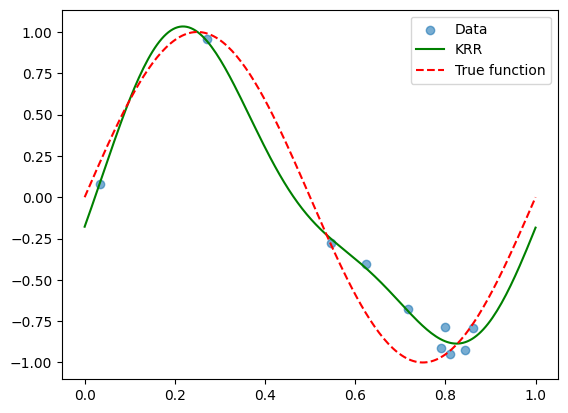

In [ ]:
# True function
def f(x):
    return np.sin(2 * np.pi * x)


np.random.seed()
N = 20
sigmaNoise = 0.1

X = np.random.rand(N)[:, None]
Xtest = np.linspace(0, 1, 200)[:, None]
ytest = f(Xtest)
y = f(X).ravel() + sigmaNoise * np.random.randn(N)


# Median heuristic for the length scale
dists = cdist( X, X, 'euclidean')
ls = np.median(dists[np.triu_indices(N, k=1)]) 
print("Median heuristic for the length scale:", ls)


# fit KRR:
def kernel(X,Y):
    return rbf_kernel(X,Y, lengthscale=ls)
ypred = predict_krr(X, y, Xtest, kernel , lam=1e-3)

# L2 error and plot
l2error = np.linalg.norm(ypred - ytest) / np.linalg.norm(ytest)
print('L2 error: ', l2error )


plt.scatter(X, y, label="Data", alpha=0.6)
plt.plot(Xtest, ypred, "g", label="KRR")
plt.plot(Xtest, ytest, "r--", label="True function")
plt.legend()
plt.show()



# Kernel Ridge Regression in higher dimensions...

Median heuristic for the length scale: 0.8941180753852502
L2 error:  0.4505652357030943


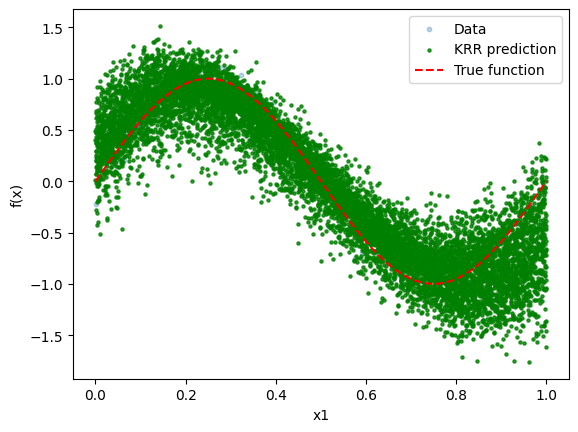

In [21]:
# New function: f(x) = sin(x1) + noise
d = 5
N = 100

X = np.random.rand(N, d)  # d inputs
sigmaNoise = 0.1
y = f(X[:, 0]) + sigmaNoise * np.random.randn(N)

# Generate a test sample
Ntest = 10000
Xtest = np.random.rand(Ntest, d)  # d inputs
ytest = f(Xtest[:, 0]) + sigmaNoise * np.random.randn(Ntest)
ytest = ytest[:,None]

# Median heuristic for the length scale
dists = cdist( X, X, 'euclidean')
ls = np.median(dists[np.triu_indices(N, k=1)])
print("Median heuristic for the length scale:", ls)

# fit KRR:
def kernel(X,Y):
    return rbf_kernel(X,Y, lengthscale=ls)
ypred = predict_krr(X, y, Xtest, kernel , lam=1e-3)


# L2 error and plot
l2error_B = np.linalg.norm(ypred - ytest) / np.linalg.norm(ytest)
print('L2 error: ', l2error_B ) 

plt.scatter(X[:, 0], y, alpha=0.3, s=10, label="Data")
plt.scatter(Xtest[:, 0], ypred, color="green", s=5, alpha=0.8, label="KRR prediction")
Xlin = np.linspace(0, 1, 200)[:, None]
plt.plot(Xlin, f(Xlin), "r--", label="True function")
plt.xlabel("x1")
plt.ylabel("f(x)")
plt.legend()
plt.show()



# 2/ Gradient-KDR routines

In [26]:

def rbf_kernel_gradient(x, X, lengthscale=1.0, B=None):
    if B is None:
        diffs = x - X
        kvec = np.exp(-0.5 * np.sum(diffs**2, axis=1) / (lengthscale**2))
        grad = (-1.0 / (lengthscale**2)) * (kvec[:, None] * diffs)
    else:
        diffs = x - X
        diffs = diffs@B
        kvec = np.exp(-0.5 * np.sum(diffs**2, axis=1) / (lengthscale**2))
        grad = (-1.0 / (lengthscale**2)) * (kvec[:, None] * diffs @ B.T)
        
    return grad


def grad_krr_at_points(X_train, alpha, kernel_gradient):
    n, p = X_train.shape
    grads = np.zeros((n, p))
    for j in range(n):
        grad_k = kernel_gradient(X_train[j], X_train)
        grads[j, :] = grad_k.T.dot(alpha)
    return grads



def gkdr(X, y, kernel, kernel_gradient, n_components=4, lam=1e-3):

    X = np.asarray(X)
    y = np.asarray(y).reshape(-1)
    n, d = X.shape

    alpha = fit_krr(X, y, kernel, lam=lam)
    grads = grad_krr_at_points(X, alpha, kernel_gradient)

    H = (grads.T @ grads) / n
    eigvals, eigvecs = eigh(H)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    W = eigvecs[:, :n_components]

    return {'W': W, 'eigvals': eigvals, 'eigvecs': eigvecs, 'grads': grads}


## Toy Example



Eigenvalues of H_hat:  [2.99294633e-02 1.20674710e-04 8.94947530e-05 7.05595954e-05
 6.68629924e-05]


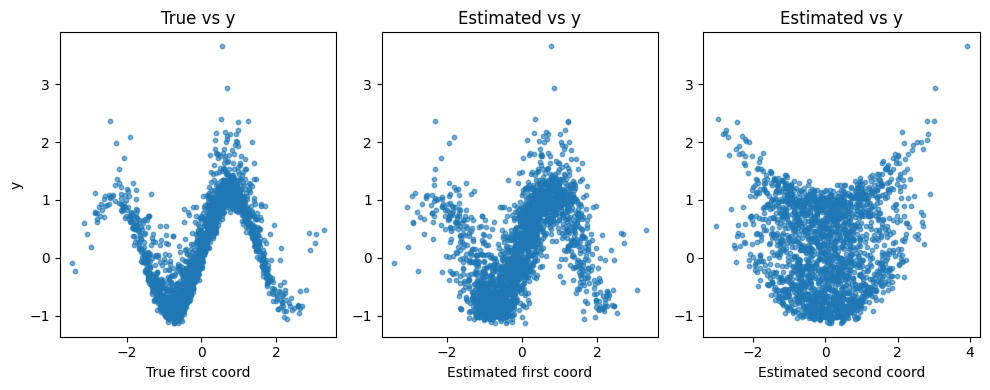

In [27]:
# New function: f(x) = sin(2*x1) + x2^2 + noise
d = 20
N = 2000

# np.random.seed(42)
X = np.random.randn(N, d) 
sigmaNoise = 0.1
y = np.sin(2*X[:, 0]) + 0.2 * X[:, 1]**2 + sigmaNoise * np.random.randn(N)

# Define the isotropic kernel (and its gradient)
dists = cdist(X, X, 'euclidean')
ls = np.median(dists[np.triu_indices(N, k=1)])
def kernel(X,Y):
    return rbf_kernel(X,Y, lengthscale=ls)
def kernel_gradient(X,Y):
    return rbf_kernel_gradient(X,Y, lengthscale=ls)

# gKDR
res = gkdr(X, y, kernel, kernel_gradient, n_components=d, lam=20)
W = res['W']

print('\n')
print('Eigenvalues of H_hat: ', res['eigvals'][0:5])

Z_est = X.dot(W)

plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.scatter(X[:,0], y, s=10, alpha=0.6)
plt.xlabel('True first coord'); plt.ylabel('y')
plt.title('True vs y')

plt.subplot(1,3,2)
plt.scatter(Z_est[:,0], y, s=10, alpha=0.6)
plt.xlabel('Estimated first coord')
plt.title('Estimated vs y')
plt.tight_layout(); 

plt.subplot(1,3,3)
plt.scatter(Z_est[:,1], y, s=10, alpha=0.6)
plt.xlabel('Estimated second coord')
plt.title('Estimated vs y')
plt.tight_layout(); plt.show()



## Kernel Ridge Regression using **anisotropic** kernel 
$$\Large
 k_B(x,x') = \left(-\frac{\|B(x-x')\|^2}{2\ell^2}\right)
$$

In [28]:
Ntest = 10000
Xtest = np.random.randn(Ntest, d)  # d inputs
sigmaNoise = 0.1
ytest = np.sin(2*Xtest[:, 0]) + 0.2 * Xtest[:, 1]**2 + sigmaNoise * np.random.randn(Ntest)
ytest = ytest[:,None]

# Compute L2 prediction using ISOTROPIC kernel
Y_pred = predict_krr(X, y, Xtest, kernel , lam=1e-3)
l2error = np.linalg.norm(Y_pred - ytest) / np.linalg.norm(ytest)
print('L2 error (isotropic kernel): ', l2error )

L2 error (isotropic kernel):  0.8491710871999849


L2 error (anisotropic):  0.47118612713594277


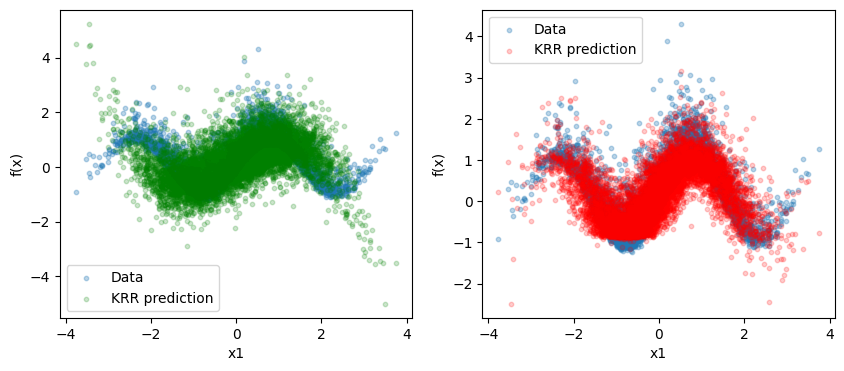

In [29]:
# Compute L2 prediction using ANISOTROPIC kernel
m = 3
B = W[:,:m]
dists = cdist( X@B, X@B, 'euclidean')
ls = np.median(dists[np.triu_indices(N, k=1)])
def kernelB(X,Y):
    return rbf_kernel(X,Y, lengthscale=ls,B=B)
def kernel_gradientB(X,Y):
    return rbf_kernel_gradient(X,Y, lengthscale=ls,B=B)

Y_pred_B = predict_krr(X, y, Xtest, kernelB , lam=1e-3)
l2error_B = np.linalg.norm(Y_pred_B - ytest) / np.linalg.norm(ytest)
print('L2 error (anisotropic): ', l2error_B )



plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(Xtest[:, 0], ytest, alpha=0.3, s=10, label="Data")
plt.scatter(Xtest[:, 0], Y_pred, color="green", s=10, alpha=0.2, label="KRR prediction")
plt.xlabel("x1")
plt.ylabel("f(x)")
plt.legend()

plt.subplot(1,2,2)
plt.scatter(Xtest[:, 0], ytest, alpha=0.3, s=10, label="Data")
plt.scatter(Xtest[:, 0], Y_pred_B, color="red", s=10, alpha=0.2, label="KRR prediction")
plt.xlabel("x1")
plt.ylabel("f(x)")
plt.legend()
plt.show()




# Iterate (improvisation...)

L2 error (isotropic   # 0):  0.8491710871999849
L2 error (anisotropic # 1 ): 0.2721294399484752
L2 error (anisotropic # 2 ): 0.19944457970087223
L2 error (anisotropic # 3 ): 0.1812051897413803
L2 error (anisotropic # 4 ): 0.17449389420681286
L2 error (anisotropic # 5 ): 0.17156346769009964


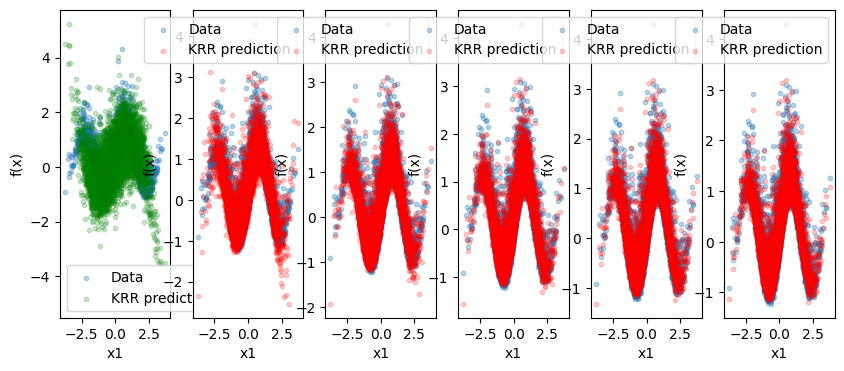

Eigenvalues of H_hat:  [5.86651198e-01 3.93871477e-04 1.59349287e-04 1.08482738e-04
 7.82848928e-05]


In [31]:

Kiter = 5

# Define the isotropic kernel (and its gradient)
dists = cdist(X, X, 'euclidean')
ls = np.median(dists[np.triu_indices(N, k=1)])
def kernelBB(X,Y):
    return rbf_kernel(X,Y, lengthscale=ls)
def kernel_gradientBB(X,Y):
    return rbf_kernel_gradient(X,Y, lengthscale=ls)


# Isotropic KRR
Y_pred_B = predict_krr(X, y, Xtest, kernelBB , lam=1e-3)
l2error_B = np.linalg.norm(Y_pred_B - ytest) / np.linalg.norm(ytest)
print('L2 error (isotropic   # 0): ', l2error )

plt.figure(figsize=(10,4))
plt.subplot(1,Kiter+1,1)
plt.scatter(Xtest[:, 0], ytest, alpha=0.3, s=10, label="Data")
plt.scatter(Xtest[:, 0], Y_pred, color="green", s=10, alpha=0.2, label="KRR prediction")
plt.xlabel("x1")
plt.ylabel("f(x)")
plt.legend()



m = d # no dimension reduction here...

for k in range(1,Kiter+1):
    # Run g-KDR
    res = gkdr(X, y, kernelBB, kernel_gradientBB, n_components=d, lam=20)
    W = res['W']

    ### Define the anisotropic kernel
    # B = W[:,:m]
    eigs = res['eigvals']
    eigs[eigs<0] =0
    B = W[:,:m] @ np.diag(eigs[:m] ** 0.2)

    dists = cdist( X@B, X@B, 'euclidean')
    ls = np.median(dists[np.triu_indices(N, k=1)])
    def kernelBB(X,Y):
        return rbf_kernel(X,Y, lengthscale=ls,B=B)
    def kernel_gradientBB(X,Y):
        return rbf_kernel_gradient(X,Y, lengthscale=ls,B=B)

    # Isoptropic KDR
    Y_pred_BB = predict_krr(X, y, Xtest, kernelBB , lam=1e-3)
    l2error_BB = np.linalg.norm(Y_pred_BB - ytest) / np.linalg.norm(ytest)

    print('L2 error (anisotropic #', k, '):', l2error_BB )


    plt.subplot(1,Kiter+1,k+1)
    plt.scatter(Xtest[:, 0], ytest, alpha=0.3, s=10, label="Data")
    plt.scatter(Xtest[:, 0], Y_pred_BB, color="red", s=10, alpha=0.2, label="KRR prediction")
    plt.xlabel("x1")
    plt.ylabel("f(x)")
    plt.legend()

plt.show()



print('Eigenvalues of H_hat: ', res['eigvals'][0:5])



## Run gKDR on Your Own data, e.g. the Boston Data set...

In [ ]:
from sklearn.datasets import fetch_openml
bdata = fetch_openml(name='boston', version=1, as_frame=True)
boston_df = bdata.frame

print(boston_df)

# #  Separate target (output of interest) and features
# y = boston_df["MEDV"].to_numpy(dtype=float)           # target as ndarray
# X = boston_df.drop(columns="MEDV").to_numpy(dtype=float)  # features as ndarray

# print("X shape:", X.shape) 
# print("Y shape:", y.shape) 


